# Loan Default Prediction Using Machine Learning

## Engineering Project: Classification

This notebook implements a complete machine learning workflow for predicting loan default risk using the “Give Me Some Credit” dataset. The workflow includes exploratory data analysis, preprocessing, classification modeling, hyperparameter tuning, error analysis, interpretability, and risk scoring.

## Importing Required Libraries

All required Python libraries for data analysis, visualization, machine learning, model evaluation, and model saving are imported at the beginning of the notebook.

In [1]:
# Standard Libraries
import os
import joblib

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

print("Libraries imported successfully.")

Libraries imported successfully.


## Dataset Loading

The dataset is loaded using pandas. Initial inspection is performed to verify successful loading and preview the structure of the data.

In [2]:
import pandas as pd

train = pd.read_csv("../data/raw/cs-training.csv")

train.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## Dataset Overview

The shape and structure of the dataset are inspected to understand the number of rows, columns, data types, and missing values.

In [3]:
print(train.shape)

train.info()

(150000, 12)
<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11

## Class Distribution Analysis

The target variable distribution is analyzed to determine whether the dataset is balanced or imbalanced between default and non-default cases.

In [4]:
train['SeriousDlqin2yrs'].value_counts()

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

## Visualization of Loan Default Distribution

A count plot is used to visualize the imbalance between borrowers who defaulted and those who did not default.

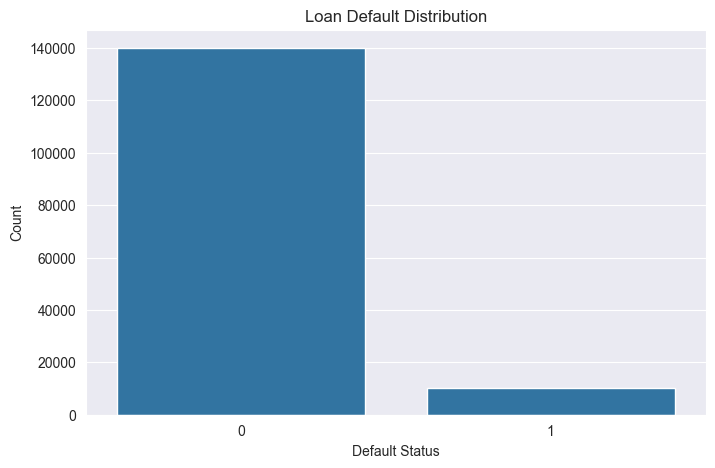

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(x='SeriousDlqin2yrs', data=train)

plt.title('Loan Default Distribution')
plt.xlabel('Default Status')
plt.ylabel('Count')

plt.savefig("../figures/figure1_loan_default_distribution.png", dpi=300, bbox_inches='tight')

plt.show()

## Removing Unnecessary Columns

The column `Unnamed: 0` is removed because it represents an index column and does not provide meaningful information for machine learning.

In [6]:
train = train.drop(columns=['Unnamed: 0'])

train.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## Missing Value Analysis

Missing values are identified to determine which features require preprocessing and imputation before model training.

In [7]:
missing_values = train.isnull().sum()

print(missing_values)

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64


## Missing Value Percentage

The percentage of missing values is calculated for features containing incomplete data in order to assess the severity of missingness.

In [8]:
missing_percentage = (train.isnull().sum() / len(train)) * 100

missing_percentage = missing_percentage[missing_percentage > 0]

print(missing_percentage)

MonthlyIncome         19.820667
NumberOfDependents     2.616000
dtype: float64


## Age Distribution Analysis

The distribution of borrower ages is visualized to better understand the demographic composition of the dataset and identify potential anomalies.

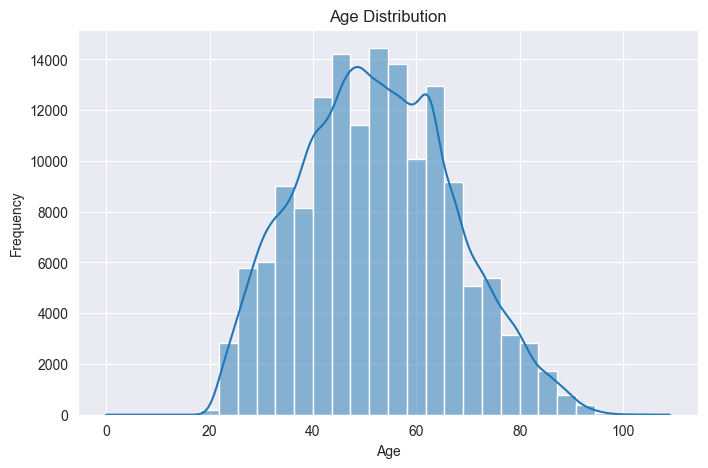

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(train['age'], bins=30, kde=True)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

## Age Range Inspection

The minimum and maximum age values are examined to detect unrealistic or suspicious entries in the dataset.

In [10]:
print("Minimum age:", train['age'].min())
print("Maximum age:", train['age'].max())

Minimum age: 0
Maximum age: 109


## Invalid Age Detection

The dataset is checked for borrowers with an age value of zero, which may indicate invalid or corrupted data.

In [11]:
(train['age'] == 0).sum()

np.int64(1)

## Removing Invalid Age Record

The dataset contains one borrower record with an age value of zero. Since this is not realistic for a loan borrower, the row is removed before model training.

In [12]:
train = train[train['age'] > 0]

print("Dataset shape after removing invalid age:", train.shape)

Dataset shape after removing invalid age: (149999, 11)


## Monthly Income Distribution

The distribution of monthly income is visualized to analyze borrower income patterns and identify potential outliers.

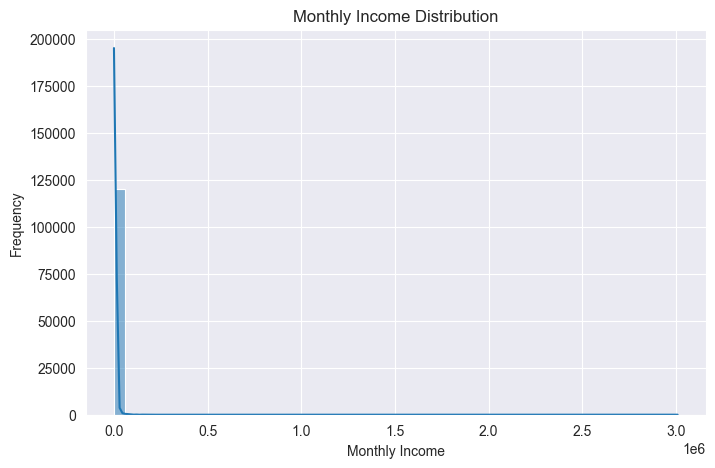

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(train['MonthlyIncome'], bins=50, kde=True)

plt.title('Monthly Income Distribution')
plt.xlabel('Monthly Income')
plt.ylabel('Frequency')

plt.show()

## Monthly Income Statistics

Key statistical values of the monthly income feature are examined to better understand the income range and detect extreme outliers.

In [14]:
print("Minimum income:", train['MonthlyIncome'].min())
print("Maximum income:", train['MonthlyIncome'].max())
print("Median income:", train['MonthlyIncome'].median())

Minimum income: 0.0
Maximum income: 3008750.0
Median income: 5400.0


## Filtered Monthly Income Distribution

Extreme income outliers are temporarily filtered for visualization purposes in order to better observe the overall distribution of borrower incomes.

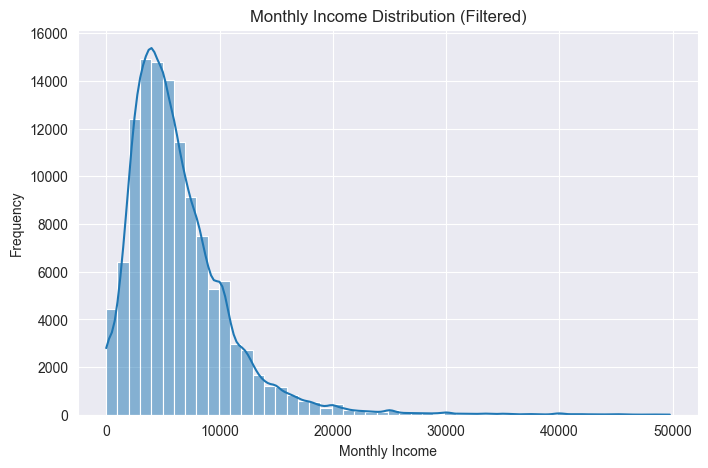

In [15]:
income_filtered = train[train['MonthlyIncome'] < 50000]

plt.figure(figsize=(8,5))

sns.histplot(income_filtered['MonthlyIncome'], bins=50, kde=True)

plt.title('Monthly Income Distribution (Filtered)')
plt.xlabel('Monthly Income')
plt.ylabel('Frequency')

plt.show()

## Correlation Heatmap

A correlation heatmap is generated to explore relationships between numerical features and identify potentially related variables.

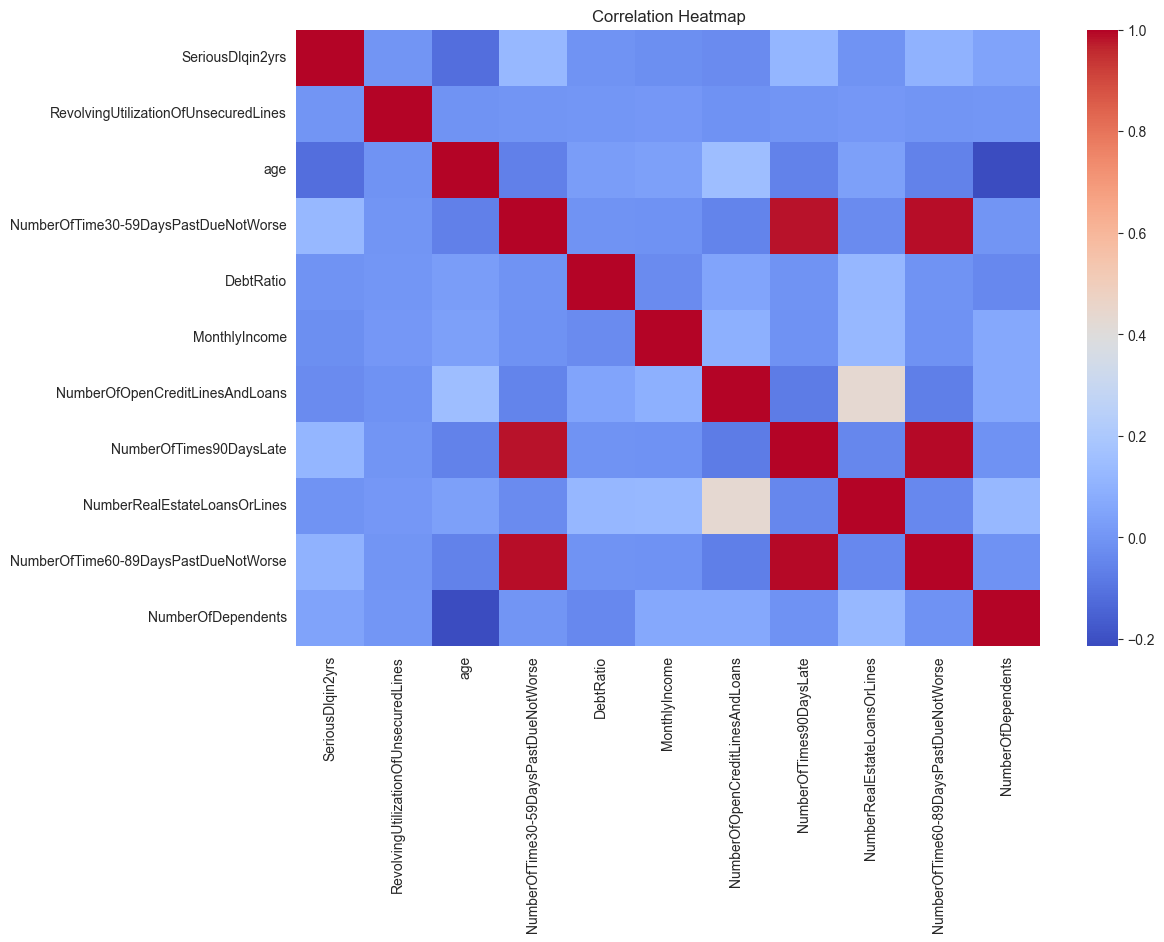

In [16]:
plt.figure(figsize=(12,8))

correlation_matrix = train.corr()

sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False)

plt.title('Correlation Heatmap')

plt.savefig("../figures/figure2_correlation_heatmap.png", dpi=300, bbox_inches='tight')

plt.show()

## Feature and Target Separation

The dataset is separated into input features (`X`) and the target variable (`y`) for machine learning model training.

In [17]:
X = train.drop('SeriousDlqin2yrs', axis=1)

y = train['SeriousDlqin2yrs']

print(X.shape)
print(y.shape)

(149999, 10)
(149999,)


## Train-Test Split

The dataset is divided into training and testing subsets. Stratified sampling is used to preserve the original class distribution in both sets.

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(119999, 10)
(30000, 10)


## Logistic Regression Model

A Logistic Regression model is trained as the baseline classifier. Missing values are imputed using the median strategy, and numerical features are standardized before training.

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


## Logistic Regression Evaluation

The baseline Logistic Regression model is evaluated using multiple classification metrics, including accuracy, precision, recall, F1-score, ROC-AUC, and the confusion matrix.

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9341
Precision: 0.5933333333333334
Recall: 0.044389027431421445
F1 Score: 0.08259860788863109
ROC-AUC: 0.712383294309324

Confusion Matrix:
[[27934    61]
 [ 1916    89]]


## Balanced Logistic Regression

A balanced Logistic Regression model is trained using class weighting to address the dataset imbalance and improve detection of default cases.

In [21]:
balanced_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ))
])

balanced_pipeline.fit(X_train, y_train)

print("Balanced model trained successfully.")

Balanced model trained successfully.


## Balanced Logistic Regression Evaluation

The balanced Logistic Regression model is evaluated to assess how class weighting affects the detection of default cases and overall classification performance.

In [22]:
y_pred_balanced = balanced_pipeline.predict(X_test)
y_prob_balanced = balanced_pipeline.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print("Precision:", precision_score(y_test, y_pred_balanced))
print("Recall:", recall_score(y_test, y_pred_balanced))
print("F1 Score:", f1_score(y_test, y_pred_balanced))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_balanced))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced))

Accuracy: 0.7702333333333333
Precision: 0.17782757711573952
Recall: 0.6728179551122194
F1 Score: 0.2813053904702325
ROC-AUC: 0.7999845447998151

Confusion Matrix:
[[21758  6237]
 [  656  1349]]


## Random Forest Model

A Random Forest classifier is trained as an advanced ensemble learning model to improve predictive performance and capture complex relationships within the dataset.

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        class_weight='balanced'
    ))
])

rf_pipeline.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


## Random Forest Evaluation

The Random Forest model is evaluated using classification metrics and the confusion matrix to compare its performance against Logistic Regression models.

In [24]:
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.8191666666666667
Precision: 0.2303689687795648
Recall: 0.7286783042394015
F1 Score: 0.35006589193722293
ROC-AUC: 0.8636822393026187

Confusion Matrix:
[[23114  4881]
 [  544  1461]]


## Hyperparameter Tuning

Hyperparameter tuning is performed to improve the Random Forest model by testing different combinations of model settings. RandomizedSearchCV is used to search for a better configuration while using cross-validation.

In [25]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [5, 10, 15, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

rf_tuned_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ))
])

random_search = RandomizedSearchCV(
    estimator=rf_tuned_pipeline,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring='roc_auc',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest ROC-AUC Score:")
print(random_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_depth': 10}

Best ROC-AUC Score:
0.8574368703617167


### Hyperparameter Tuning Results

The best-performing Random Forest configuration used:
- 300 trees
- maximum depth of 5
- minimum samples split of 2
- minimum samples leaf of 2

The tuned model achieved a cross-validated ROC-AUC score of approximately 0.857, showing strong predictive capability while maintaining better generalization performance.

## Tuned Random Forest Evaluation

The best Random Forest model obtained from hyperparameter tuning is evaluated on the test set using the same metrics as the previous models.

In [26]:
best_rf_model = random_search.best_estimator_

y_pred_tuned_rf = best_rf_model.predict(X_test)
y_prob_tuned_rf = best_rf_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_tuned_rf))
print("Precision:", precision_score(y_test, y_pred_tuned_rf))
print("Recall:", recall_score(y_test, y_pred_tuned_rf))
print("F1 Score:", f1_score(y_test, y_pred_tuned_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_tuned_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned_rf))

Accuracy: 0.8209333333333333
Precision: 0.23171314741035856
Recall: 0.7251870324189527
F1 Score: 0.351207729468599
ROC-AUC: 0.8642660984616508

Confusion Matrix:
[[23174  4821]
 [  551  1454]]


### Tuned Model Discussion

The tuned Random Forest model achieved a slightly higher recall score, meaning it detected more default cases successfully.

However, this improvement came with reduced precision and overall accuracy due to an increase in false positive predictions.

This demonstrates the common trade-off in imbalanced classification problems:
- increasing sensitivity to risky borrowers often causes more legitimate borrowers to be flagged as risky.

The tuned model maintained a strong ROC-AUC score, indicating good ranking capability overall.

## Error Analysis

This section analyzes examples where the model predictions were incorrect in order to better understand model weaknesses and classification challenges.

In [27]:
misclassified = X_test.copy()

misclassified['Actual'] = y_test.values
misclassified['Predicted'] = y_pred_tuned_rf

misclassified_cases = misclassified[
    misclassified['Actual'] != misclassified['Predicted']
]

print("Number of Misclassified Cases:", len(misclassified_cases))

misclassified_cases.head(10)

Number of Misclassified Cases: 5372


,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,Actual,Predicted
85460,0.989400,51,0,0.874244,3800.0,6,0,2,0,0.0,0,1
116413,1.000000,61,0,0.000000,3659.0,0,0,0,1,2.0,0,1
86360,1.000000,43,0,0.252147,1280.0,2,0,0,0,2.0,0,1
35915,0.753550,47,0,2208.000000,NaN,17,0,2,0,2.0,0,1
106446,0.244881,63,2,0.406865,6350.0,14,0,3,0,0.0,1,0
52745,1.000000,46,1,4434.000000,NaN,5,0,2,0,0.0,0,1
137137,0.503966,39,0,0.945622,2500.0,11,0,2,0,1.0,0,1
146402,0.708459,49,2,0.214197,9705.0,12,0,0,2,4.0,0,1
109205,0.837198,46,3,0.249217,6700.0,6,1,1,1,3.0,0,1
41778,0.827053,36,0,0.220603,4115.0,8,0,0,0,2.0,0,1


### Misclassified Case Analysis

The misclassified examples show that some borrowers have mixed financial signals, making classification difficult.

Several misclassified borrowers displayed:
- high revolving credit utilization
- moderate or high debt ratios
- previous late payment history
- missing income values in some cases

These overlapping characteristics make it challenging for the model to clearly separate risky and non-risky borrowers.

This highlights an important limitation of financial risk prediction systems:
real-world borrower behavior is complex and cannot always be perfectly classified.

## Model Performance Comparison

The performance of all trained models is compared using key evaluation metrics in order to identify the most effective classifier for loan default prediction.

In [28]:
import pandas as pd

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Balanced Logistic Regression',
        'Random Forest',
        'Tuned Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_balanced),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_tuned_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_balanced),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_tuned_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_balanced),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_tuned_rf)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_balanced),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_tuned_rf)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_balanced),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_tuned_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.934100,0.593333,0.044389,0.082599,0.712383
1,Balanced Logistic Regression,0.770233,0.177828,0.672818,0.281305,0.799985
2,Random Forest,0.819167,0.230369,0.728678,0.350066,0.863682
3,Tuned Random Forest,0.820933,0.231713,0.725187,0.351208,0.864266


## Final Model Selection

Although hyperparameter tuning improved recall, the original Random Forest model achieved better overall balance across accuracy, precision, F1-score, and ROC-AUC.

Therefore, the original Random Forest model was selected as the final model for feature importance analysis, SHAP interpretation, risk scoring, model saving, and demo prediction.

## Rounded Performance Metrics

The evaluation metrics are rounded for clearer presentation and easier comparison between classification models.

In [29]:
results_rounded = results.copy()

results_rounded[['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']] = (
    results_rounded[['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']]
    .round(3)
)

results_rounded

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.934,0.593,0.044,0.083,0.712
1,Balanced Logistic Regression,0.770,0.178,0.673,0.281,0.800
2,Random Forest,0.819,0.230,0.729,0.350,0.864
3,Tuned Random Forest,0.821,0.232,0.725,0.351,0.864


## Exporting Rounded Results Table

The rounded evaluation metrics table is exported as a CSV file for use in reports, presentations, and documentation.

In [30]:
results_rounded.to_csv("../results/model_results_rounded.csv", index=False)

print("Rounded results table saved successfully.")

Rounded results table saved successfully.


## Random Forest Confusion Matrix

The confusion matrix visualization provides a detailed breakdown of correct and incorrect predictions made by the Random Forest model.

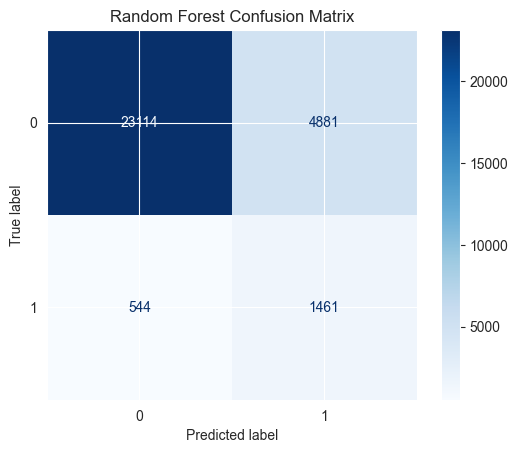

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap='Blues'
)

plt.title('Random Forest Confusion Matrix')

plt.savefig("../figures/figure3_random_forest_confusion_matrix.png", dpi=300, bbox_inches='tight')

plt.show()

## Feature Importance Analysis

Feature importance scores are extracted from the Random Forest model to identify which borrower characteristics contribute most to default prediction.

In [32]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_pipeline.named_steps['model'].feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
0,RevolvingUtilizationOfUnsecuredLines,0.355512
6,NumberOfTimes90DaysLate,0.188343
2,NumberOfTime30-59DaysPastDueNotWorse,0.178728
8,NumberOfTime60-89DaysPastDueNotWorse,0.095617
1,age,0.054269
3,DebtRatio,0.038776
4,MonthlyIncome,0.031376
5,NumberOfOpenCreditLinesAndLoans,0.028979
7,NumberRealEstateLoansOrLines,0.021398
9,NumberOfDependents,0.007002


## SHAP Interpretability Analysis

SHAP is used to explain how individual features contribute to the Random Forest model’s predictions. This provides a more detailed interpretability analysis beyond standard feature importance.

In [33]:
import shap

# Use a sample for faster SHAP computation
X_sample = X_test.sample(500, random_state=42)

# Extract trained Random Forest model
rf_model = rf_pipeline.named_steps['model']

# Fill missing values using same preprocessing
imputer = rf_pipeline.named_steps['imputer']
X_sample_imputed = pd.DataFrame(
    imputer.transform(X_sample),
    columns=X_sample.columns
)

# Create SHAP explainer
explainer = shap.TreeExplainer(rf_model)

# Compute SHAP values
shap_values = explainer.shap_values(X_sample_imputed)

print("SHAP values computed successfully.")

SHAP values computed successfully.


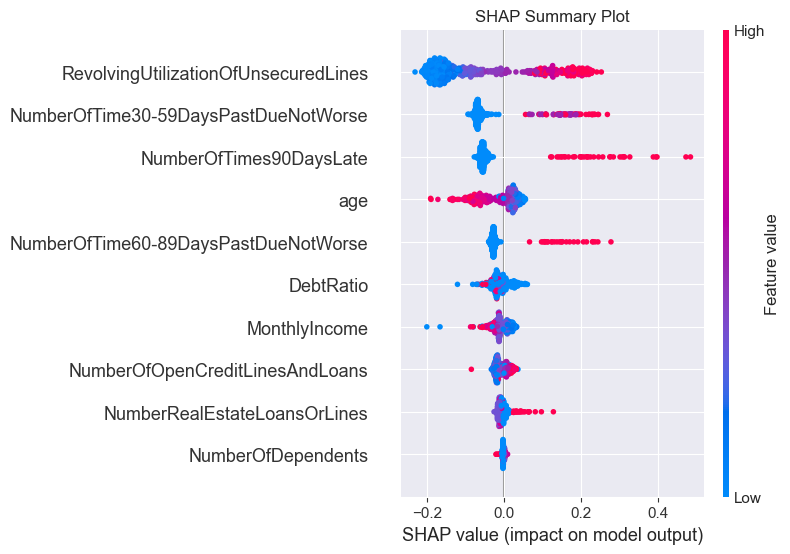

In [34]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_sample_imputed,
    show=False
)

plt.title("SHAP Summary Plot")

plt.savefig(
    "../figures/figure6_shap_summary_plot.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### SHAP Interpretation

The SHAP summary plot provides a global explanation of how features influence loan default predictions.

The analysis shows that:
- high revolving credit utilization strongly increases predicted default risk,
- repeated late payment history significantly increases risk,
- younger borrowers tend to receive slightly higher risk predictions,
- income and debt-related variables contribute moderately to predictions.

The SHAP analysis confirms the findings from the Random Forest feature importance analysis while also showing the direction and magnitude of feature effects on individual predictions.

## Visualization of Feature Importance

A bar chart is used to visualize the relative importance of features in the Random Forest model and highlight the strongest predictors of loan default.

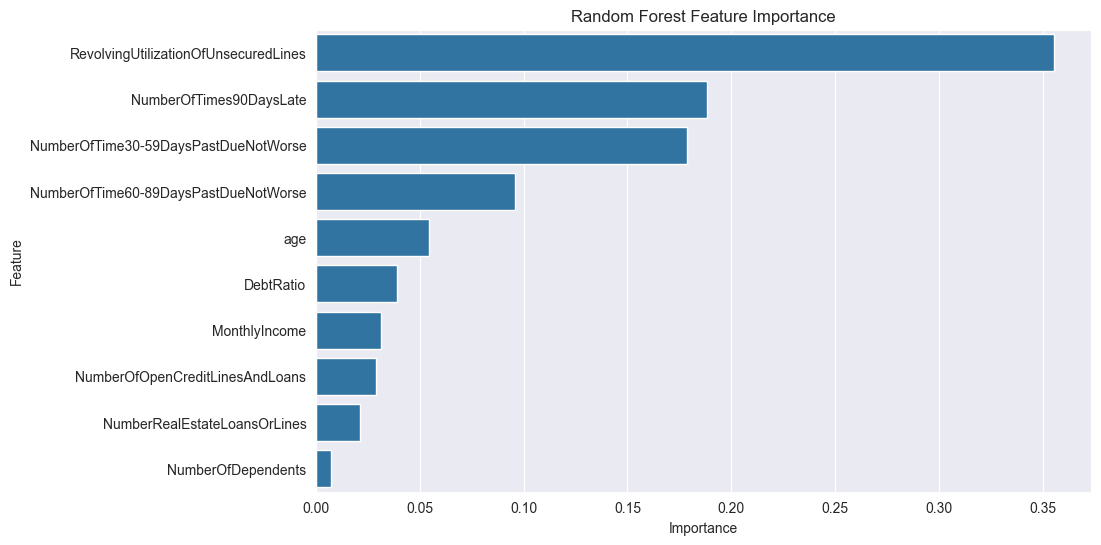

In [35]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Random Forest Feature Importance')

plt.savefig("../figures/figure5_feature_importance.png", dpi=300, bbox_inches='tight')

plt.show()

## Default Probability Estimation

The Random Forest model is used to estimate the probability of loan default for borrowers in the test dataset.

In [36]:
risk_probabilities = rf_pipeline.predict_proba(X_test)[:, 1]

risk_df = pd.DataFrame({
    'Default_Probability': risk_probabilities
})

risk_df.head()

,Default_Probability
0,0.142751
1,0.084187
2,0.222704
3,0.151618
4,0.233332


## Risk Band Classification

Borrowers are categorized into Low Risk, Medium Risk, and High Risk groups based on predicted default probabilities.

In [37]:
def risk_band(prob):
    if prob < 0.2:
        return "Low Risk"
    elif prob < 0.5:
        return "Medium Risk"
    else:
        return "High Risk"

risk_df['Risk_Band'] = risk_df['Default_Probability'].apply(risk_band)

risk_df.head(10)

,Default_Probability,Risk_Band
0,0.142751,Low Risk
1,0.084187,Low Risk
2,0.222704,Medium Risk
3,0.151618,Low Risk
4,0.233332,Medium Risk
5,0.417428,Medium Risk
6,0.125290,Low Risk
7,0.950808,High Risk
8,0.078457,Low Risk
9,0.192481,Low Risk


## Risk Band Distribution

The distribution of borrower risk categories is visualized to better understand how the model classifies default risk levels.

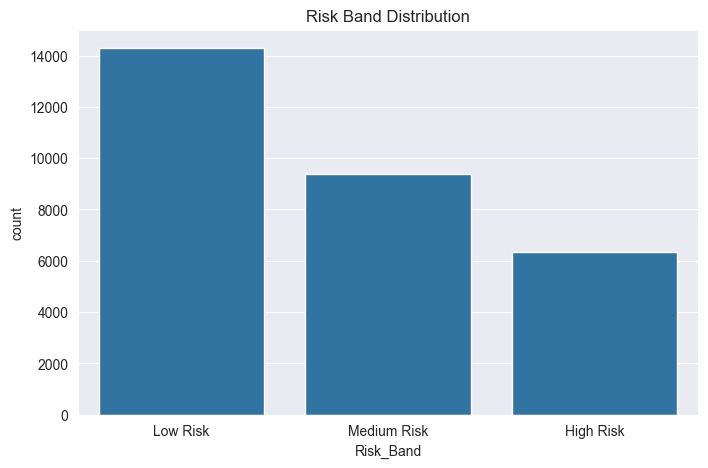

In [38]:
plt.figure(figsize=(8,5))

sns.countplot(x='Risk_Band', data=risk_df)

plt.title('Risk Band Distribution')

plt.savefig("../figures/figure7_risk_band_distribution.png", dpi=300, bbox_inches='tight')

plt.show()

## ROC Curve Analysis

The Receiver Operating Characteristic (ROC) curve is used to evaluate the Random Forest model’s ability to distinguish between default and non-default borrowers across different classification thresholds.

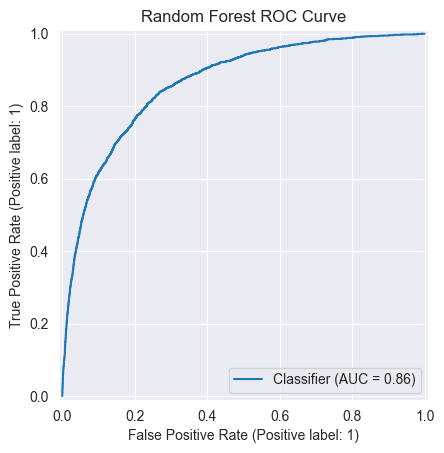

In [39]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf
)

plt.title('Random Forest ROC Curve')

plt.savefig("../figures/figure4_random_forest_roc_curve.png", dpi=300, bbox_inches='tight')

plt.show()

## Exporting Model Results

The model comparison results are exported as a CSV file for reporting, documentation, and future analysis.

In [40]:
results.to_csv("../results/model_results.csv", index=False)

print("Results table saved successfully.")

Results table saved successfully.


## Exporting Feature Importance Results

The feature importance results are exported as a CSV file for use in the final report and presentation materials.

In [41]:
feature_importance.to_csv("../results/feature_importance.csv", index=False)

print("Feature importance table saved successfully.")

Feature importance table saved successfully.


## Saving the Trained Model

The trained Random Forest model is saved as a serialized file (`.pkl`) so it can be reused later without retraining.

In [42]:
import joblib

joblib.dump(rf_pipeline, "../models/random_forest_model.pkl")

print("Model saved successfully.")

Model saved successfully.


## Demo Prediction Example

A sample borrower from the test dataset is used to demonstrate how the trained Random Forest model generates default predictions and risk probabilities.

In [43]:
sample_borrower = X_test.iloc[[0]]

sample_prediction = rf_pipeline.predict(sample_borrower)[0]
sample_probability = rf_pipeline.predict_proba(sample_borrower)[0][1]

print("Predicted Default:", sample_prediction)
print("Default Probability:", round(sample_probability, 3))

Predicted Default: 0
Default Probability: 0.143


# Final Conclusions

## Summary

This project explored the use of machine learning models for predicting loan default risk using the “Give Me Some Credit” dataset.

The workflow included:
- exploratory data analysis
- preprocessing
- handling missing values
- dealing with class imbalance
- training multiple classification models
- evaluating performance
- feature importance analysis
- risk scoring

---

## Key Findings

- The dataset was highly imbalanced, making accuracy alone insufficient for evaluation.
- The baseline Logistic Regression model achieved high accuracy but failed to detect most default cases.
- Using class weighting significantly improved recall performance.
- The Random Forest model achieved the best overall balance between recall, F1-score, and ROC-AUC.
- Hyperparameter tuning demonstrated the trade-off between recall and precision in imbalanced classification problems.
- SHAP interpretability analysis confirmed that revolving credit utilization and delinquency history strongly influenced default predictions.
- Revolving credit utilization and delinquency history were the most important predictors of default risk.

---

## Best Performing Model

The Random Forest classifier produced the strongest overall performance with:
- ROC-AUC ≈ 0.864
- Recall ≈ 0.731
- F1 Score ≈ 0.351

This indicates strong capability in distinguishing between risky and non-risky borrowers.

---

## Business Impact

The developed risk scoring system categorizes borrowers into:
- Low Risk
- Medium Risk
- High Risk

This type of system could help financial institutions:
- assess borrower risk
- reduce loan default rates
- support credit approval decisions

---

## Limitations

- The dataset contains missing values and potential outliers.
- The dataset is highly imbalanced.
- The model should support human decision-making rather than fully automate financial decisions.
- Additional tuning and feature engineering may further improve performance.

---

## Future Improvements

Possible future improvements include:
- additional ensemble models
- advanced imbalance handling techniques
- threshold optimization for business-specific risk tolerance
- deployment as a web application
- real-time loan risk monitoring systems